In [2]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

from ptychozoon.enhance import ElementMap, FluorescenceDataset, Product, VSPIFluorescenceEnhancingAlgorithm
from ptychozoon.settings import DeconvolutionEnhancementSettings
from ptychozoon.viewer import show_vspi_results

from chronos import plotting as tplot
from chronos.timer_utils import toggle_timer, clear_timer_globals

Can you add a cell after the cell with "vspi_results = [x for x in vspi_runner]" that has an ipywidget that displays the 

## Generate Data

In [3]:
# width of the probe array in pixels; also determines the distance between
# the edge of the outer edge probe positions and the outer edge of the dummy
# fluorescence array
probe_array_width = 64
# determines the width of the gaussian probe
gaussian_probe_sigma = 7
# approximate number of probe positions; actual count = n_rows * n_cols
n_positions = 30e3


### 1. Make ptycho array and fluorescence arrays

To run this simulation, download the image from this wikipedia link: https://en.wikipedia.org/wiki/European_robin#/media/File:Erithacus_rubecula_with_cocked_head.jpg

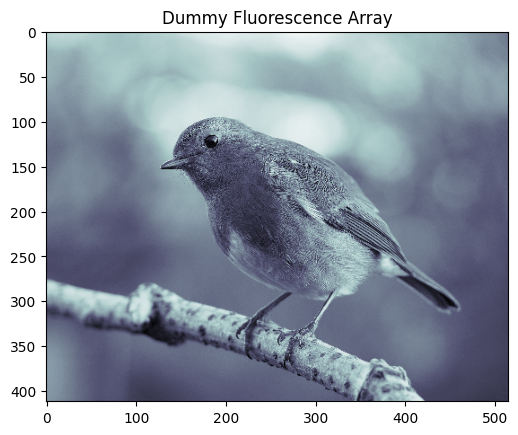

In [4]:
img = Image.open("/local/Erithacus_rubecula_with_cocked_head.jpg")   # Load image
s = 5
sample_image = np.array(img).mean(2)[::s, ::s] * 1

plt.title("Dummy Fluorescence Array")
plt.imshow(sample_image, cmap="bone")
plt.show()

In [5]:
object_size = sample_image.shape
element_maps_truth = [ElementMap(name="rubecula", counts_per_second=sample_image)]

### 2. Make probe positions

Grid: 149 rows x 202 cols = 30098 positions


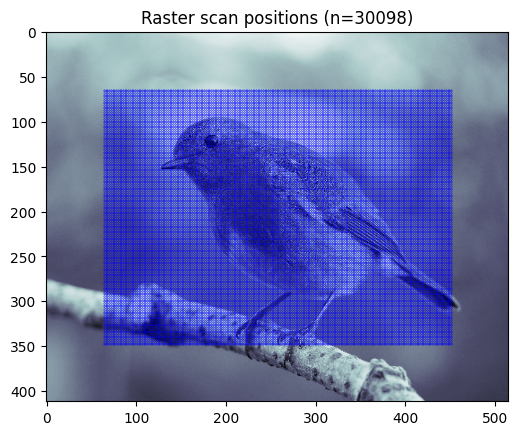

In [6]:
# Raster scan positions covering the area 'padding' pixels from the object edge
padding = probe_array_width
scan_row_min = padding
scan_row_max = object_size[0] - padding
scan_col_min = padding
scan_col_max = object_size[1] - padding

scan_height = scan_row_max - scan_row_min
scan_width  = scan_col_max - scan_col_min

# Grid dimensions that preserve the scan area aspect ratio
aspect = scan_height / scan_width
n_cols = max(1, int(np.round(np.sqrt(n_positions / aspect))))
n_rows = max(1, int(np.round(n_positions / n_cols)))

row_coords = np.linspace(scan_row_min, scan_row_max, n_rows)
col_coords = np.linspace(scan_col_min, scan_col_max, n_cols)

# Raster scan: all rows go left to right
positions = np.array([
    [r, c]
    for r in row_coords
    for c in col_coords
])  # shape: (n_rows * n_cols, 2)  —  axis 0 = row, axis 1 = col (pixels)

print(f"Grid: {n_rows} rows x {n_cols} cols = {len(positions)} positions")

# Visualise scan path overlaid on the object phase
plt.figure()
plt.imshow(element_maps_truth[0].counts_per_second, cmap="bone", origin="upper")
plt.plot(positions[:, 1], positions[:, 0], ".b", lw=0.5, alpha=1, ms=.5)
plt.title(f"Raster scan positions (n={len(positions)})")
plt.show()

### 3. Make probe

Probe FWHM: 19.79898987322333


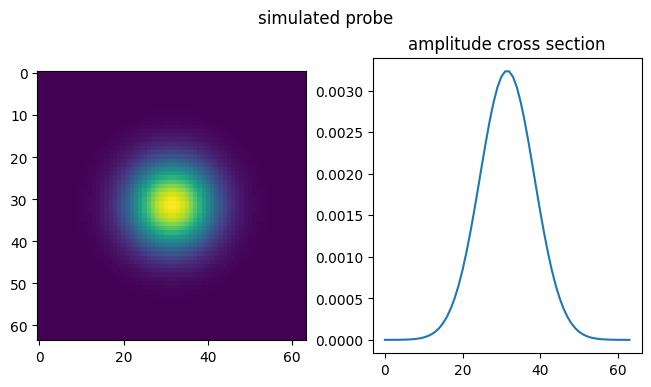

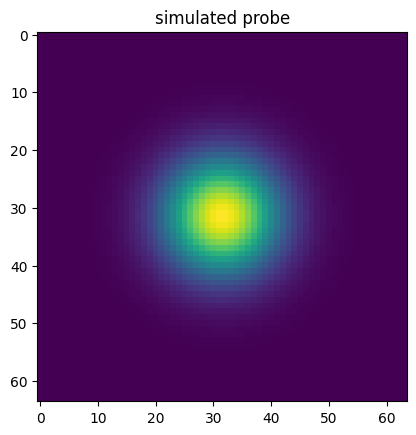

In [7]:
# Generate complex Gaussian probe
probe_size = (padding, padding)
probe_width = gaussian_probe_sigma
print(f"Probe FWHM: {probe_width * 2 * np.sqrt(2*np.log2(2))}")

# Coordinate grids centred on zero
y = np.linspace(-(probe_size[0] - 1) / 2, (probe_size[0] - 1) / 2, probe_size[0])
x = np.linspace(-(probe_size[1] - 1) / 2, (probe_size[1] - 1) / 2, probe_size[1])
Y, X = np.meshgrid(y, x, indexing="ij")

probe = np.exp(-(X**2 + Y**2) / (2 * probe_width**2)).astype(np.complex128)
probe /= np.sqrt(np.sum(np.abs(probe) ** 2))  # normalise to unit energy
probe /= np.abs(probe).sum()

fig, ax = plt.subplots(1, 2, layout="compressed")
fig.suptitle("simulated probe")
plt.sca(ax[0])
plt.imshow(np.abs(probe))
plt.sca(ax[1])
plt.title("amplitude cross section")
plt.plot(np.abs(probe)[padding // 2])
# plt.axis("off")
plt.show()

plt.title("simulated probe")
plt.imshow(np.abs(probe))
plt.show()


### 4. Get convolved XRF arrays
i.e. simulate XRF measurement

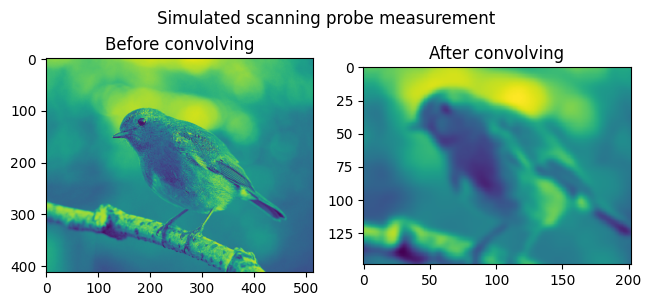

In [8]:
from scipy.signal import fftconvolve

# Use probe intensity (|probe|^2) as PSF, matching the forward model in enhance.py
probe_intensity = np.abs(probe) ** 2
probe_intensity = probe_intensity / probe_intensity.sum()

# Convolve full object with probe PSF, then sample at scan positions.
# conv_result[r, c] = integral of PSF * element_map_patch centred at (r, c)
element_maps_convolved = []
for element_map in element_maps_truth:
    conv_result = fftconvolve(element_map.counts_per_second, probe_intensity, mode="same")

    # Sample at each scan position (positions are already integer-valued from linspace,
    # but round to be safe)
    pos_idx = np.round(positions).astype(int)
    measurements_flat = conv_result[pos_idx[:, 0], pos_idx[:, 1]]

    # Reshape to (n_rows, n_cols). Raster scan order matches probe_positions order,
    # so this is directly visualizable.
    measurements = np.abs(measurements_flat.reshape(n_rows, n_cols))

    fig, ax = plt.subplots(1, 2, layout="compressed")
    plt.sca(ax[0])
    plt.title("Before convolving")
    plt.imshow(element_map.counts_per_second)#, aspect="auto")
    plt.sca(ax[1])
    plt.title("After convolving")
    ax[1].imshow(measurements)#, aspect="auto")
    plt.suptitle("Simulated scanning probe measurement")
    plt.show()

    element_maps_convolved += [ElementMap(element_map.name, measurements)]

### 5. Package data into `ptychozoon` objects

In [9]:
dummy_ptycho_object = np.zeros_like(element_maps_truth[0].counts_per_second, dtype=np.complex128)

In [10]:
# package data
# ptycho
pixel_size_m = 1
probe_positions = positions - np.array(dummy_ptycho_object.shape) / 2
# probe_positions += -np.array((probe.shape[0] / 2,) * 2)
ptycho_in = Product(
    probe_positions=probe_positions,
    probe=probe[None],
    object_array=dummy_ptycho_object,
    pixel_size_m=(pixel_size_m,) * 2,
    object_center_m=np.array([0, 0]),
)
# fluorescence
flourescence_in = FluorescenceDataset(element_maps_convolved)


## Run enhancement

### Define results plotting functions

In [11]:
def plot_result_images(
    element_map_truth: ElementMap,
    element_map_input: ElementMap,
    element_map_enhanced: ElementMap,
):
    fig, ax = plt.subplots(1, 3, layout="compressed", figsize=(10, 10))
    plt.sca(ax[0])
    plt.title(f"{element_map_truth.name}\ntruth")
    plt.imshow(element_map_truth.counts_per_second, cmap="bone")
    # plt.colorbar()
    plt.sca(ax[1])
    plt.title(f"{element_map_input.name}\nconvolved")
    plt.imshow(element_map_input.counts_per_second, cmap="bone")
    # plt.colorbar()
    plt.sca(ax[2])
    plt.title(f"{element_map_enhanced.name}\nfluorescence-enhanced")
    plt.imshow(element_map_enhanced.counts_per_second, cmap="bone")
    # plt.colorbar()
    plt.show()


def plot_result_cross_sections(
    element_map_truth: ElementMap,
    element_map_input: ElementMap,
    element_map_enhanced: ElementMap,
    xrf_array_width_in_pixels: float,
):
    labels = ["convolved", "enhanced", "truth"]
    arrays_in = [
        element_map_input.counts_per_second,
        element_map_enhanced.counts_per_second,
        element_map_truth.counts_per_second,
    ]
    slice_idx = []
    lw = 2
    fig, ax = plt.subplots(1, figsize=(4, 4))
    for i, arr in enumerate(arrays_in):
        slice_idx = arr.shape[1] // 2
        print(slice_idx)
        if i == 0:
            x = np.linspace(
                -xrf_array_width_in_pixels / 2,
                xrf_array_width_in_pixels / 2,
                len(arr[slice_idx]),
            )
            plt.plot(x, arr[slice_idx], label=labels[i], lw=lw, alpha=1)
        elif i == 1:
            w0 = len(arr[slice_idx])
            x = np.linspace(-w0 / 2, w0 / 2, len(arr[slice_idx]))
            plt.plot(x, arr[slice_idx], label=labels[i], zorder=-4, alpha=1)
        elif i == 2:
            w0 = len(arr[slice_idx])
            x = np.linspace(-w0 / 2, w0 / 2, len(arr[slice_idx]))
            plt.plot(x, arr[slice_idx], label=labels[i], zorder=-5, color="k")
    plt.grid(ls=":", zorder=-99)
    # plt.autoscale(True, "x", True)
    plt.legend(fontsize=10)  # , loc="lower right")
    plt.show()


### results: fourier

In [12]:
settings = DeconvolutionEnhancementSettings()
settings.solver = "lsmr"
settings.lsmr.max_iter = 20
settings.lsmr.checkpoint_interval = 1
settings.lsmr.damping_factor = 0

clear_timer_globals()
toggle_timer(True)
vspi_runner = VSPIFluorescenceEnhancingAlgorithm().enhance(
    flourescence_in,
    ptycho_in,
    settings=settings,
)

In [ ]:
vspi_results = [x for x in vspi_runner]

  0%|                                                                                                                                   | 0/1 [00:00<?, ?it/s]

In [3]:
%matplotlib qt
viewer = show_vspi_results(vspi_results, block=False)

ImportError: Failed to import any of the following Qt binding modules: PyQt6, PySide6, PyQt5, PySide2

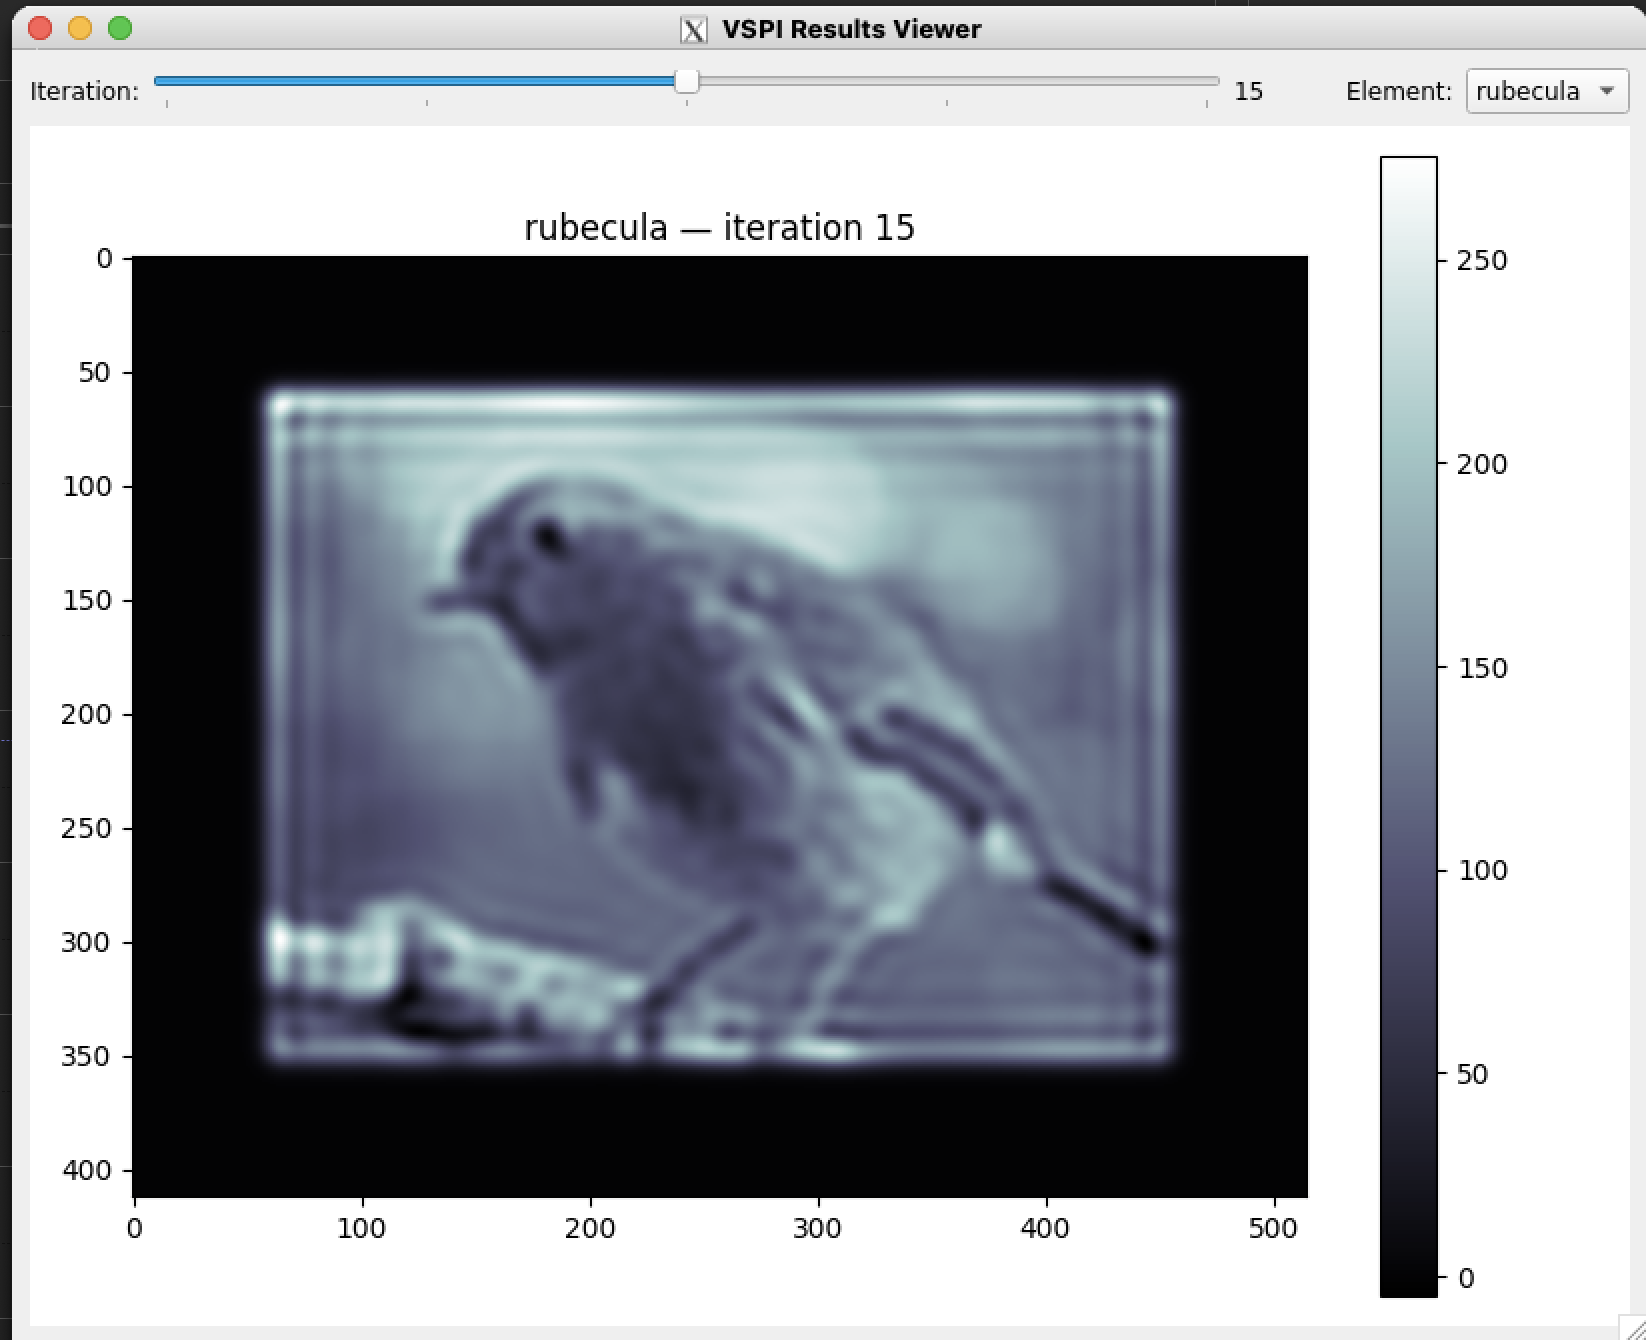

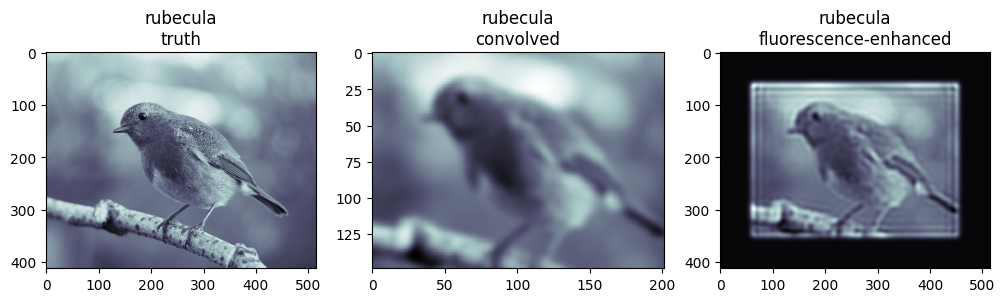

101
257
257


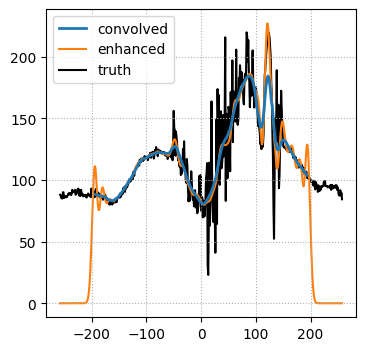

In [25]:
%matplotlib inline
result_idx = -1
for i in range(len(vspi_results[result_idx][0].element_maps)):
    plot_result_images(
        element_maps_truth[i],
        flourescence_in.element_maps[i],
        vspi_results[result_idx][0].element_maps[i],
    )

    plot_result_cross_sections(
        element_maps_truth[i],
        flourescence_in.element_maps[i],
        vspi_results[result_idx][0].element_maps[i],
        xrf_array_width_in_pixels=col_coords[-1] - col_coords[0],
    )

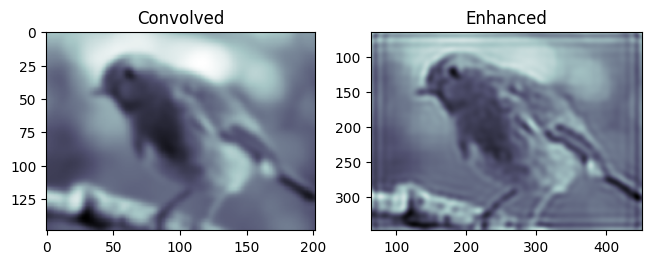

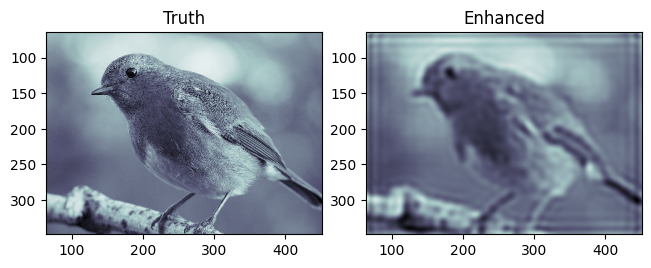

In [ ]:
i = 0
fig, ax = plt.subplots(1, 2, layout="compressed")
plt.sca(ax[0])
arr = flourescence_in.element_maps[i].counts_per_second
plt.imshow(arr, cmap="bone")
plt.title("Convolved")
plt.sca(ax[1])
plt.title("Enhanced")
arr = vspi_results[result_idx][0].element_maps[i].counts_per_second
plt.imshow(arr, cmap="bone")
plt.xlim([padding, arr.shape[1] - padding])
plt.ylim([arr.shape[0] - padding, padding])
plt.show()

i = 0
fig, ax = plt.subplots(1, 2, layout="compressed")
plt.sca(ax[0])
arr = element_maps_truth[0].counts_per_second
plt.imshow(arr, cmap="bone")
plt.title("Truth")
plt.sca(ax[1])
plt.title("Enhanced")
arr = vspi_results[result_idx][0].element_maps[i].counts_per_second
plt.imshow(arr, cmap="bone")
for i in range(2):
    plt.sca(ax[i])
    plt.xlim([padding, arr.shape[1] - padding])
    plt.ylim([arr.shape[0] - padding, padding])
plt.show()


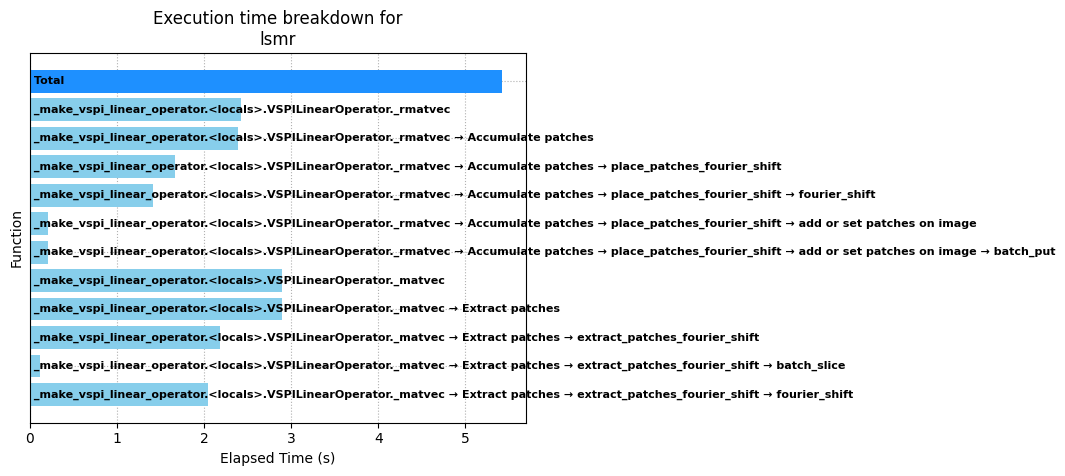

Execution summary of lsmr

Total execution time: 5.42 s

Execution times:
1. _make_vspi_linear_operator.<locals>.VSPILinearOperator._rmatvec: 2.4 s
2. Accumulate patches: 2.4 s
3. place_patches_fourier_shift: 1.7 s
4. fourier_shift: 1.4 s
5. add or set patches on image: 0.22 s
6. batch_put: 0.22 s
7. _make_vspi_linear_operator.<locals>.VSPILinearOperator._matvec: 2.9 s
8. Extract patches: 2.9 s
9. extract_patches_fourier_shift: 2.2 s
10. batch_slice: 0.12 s
11. fourier_shift: 2 s

Function call stack info:
Ordered by time of first function call
1. _make_vspi_linear_operator.<locals>.VSPILinearOperator._rmatvec
2. _make_vspi_linear_operator.<locals>.VSPILinearOperator._rmatvec → Accumulate patches
3. _make_vspi_linear_operator.<locals>.VSPILinearOperator._rmatvec → Accumulate patches → place_patches_fourier_shift
4. _make_vspi_linear_operator.<locals>.VSPILinearOperator._rmatvec → Accumulate patches → place_patches_fourier_shift → fourier_shift
5. _make_vspi_linear_operator.<locals>.VSP

In [28]:
tplot.plot_elapsed_time_bar_plot_advanced("lsmr", use_long_bar_labels=True);